In [43]:
import jax
import jax.numpy as jnp
from functools import partial
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt
import optax

jax.config.update("jax_enable_x64", True)

class MMD:

    def __init__(self, scales, space):
        gammas = 1 / (2 * (scales**2))
        sq_dists = jnp.abs(space[:, None] - space[None, :]) ** 2
        self.K = sum(jnp.exp(-gamma * sq_dists) for gamma in gammas) / len(scales)
        self.scales = scales

    def k_expval(self, px, py):
        # Kernel expectation value
        return px @ self.K @ py

    def __call__(self, px, py):
        pxy = px - py
        return self.k_expval(pxy, pxy)

class QCBM:
    def __init__(self, circ, mmd, py):
        self.circ = circ
        self.mmd = mmd
        self.py = py

    @partial(jax.jit, static_argnums=(0,))
    def mmd_loss(self, params):
        px = self.circ(params)
        return self.mmd(px, self.py), px


In [44]:
def get_bars_and_stripes(n):
    bitstrings = [list(np.binary_repr(i, n))[::-1] for i in range(2**n)]
    bitstrings = np.array(bitstrings, dtype=int)

    stripes = bitstrings.copy()
    stripes = np.repeat(stripes, n, 0)
    stripes = stripes.reshape(2**n, n * n)

    bars = bitstrings.copy()
    bars = bars.reshape(2**n * n, 1)
    bars = np.repeat(bars, n, 1)
    bars = bars.reshape(2**n, n * n)
    return np.vstack((stripes[0 : stripes.shape[0] - 1], bars[1 : bars.shape[0]]))


n = 3
size = n**2
data = get_bars_and_stripes(n)
print(data.shape)


(14, 9)



Sample bitstring: 100100100


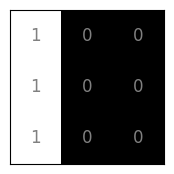

In [45]:
sample = data[1].reshape(n, n)

plt.figure(figsize=(2, 2))
plt.imshow(sample, cmap="gray", vmin=0, vmax=1)
plt.grid(color="gray", linewidth=2)
plt.xticks([])
plt.yticks([])

for i in range(n):
    for j in range(n):
        text = plt.text(
            i,
            j,
            sample[j][i],
            ha="center",
            va="center",
            color="gray",
            fontsize=12,
        )

print(f"\nSample bitstring: {''.join(np.array(sample.flatten(), dtype='str'))}")

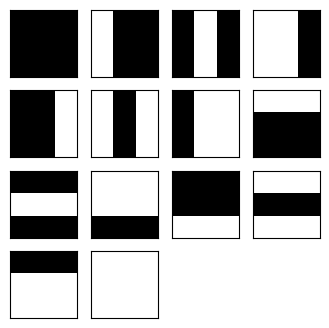

In [46]:
plt.figure(figsize=(4, 4))
j = 1
for i in data:
    plt.subplot(4, 4, j)
    j += 1
    plt.imshow(np.reshape(i, (n, n)), cmap="gray", vmin=0, vmax=1)
    plt.xticks([])
    plt.yticks([])

[0, 292, 146, 438, 73, 365, 219, 448, 56, 504, 7, 455, 63, 511]


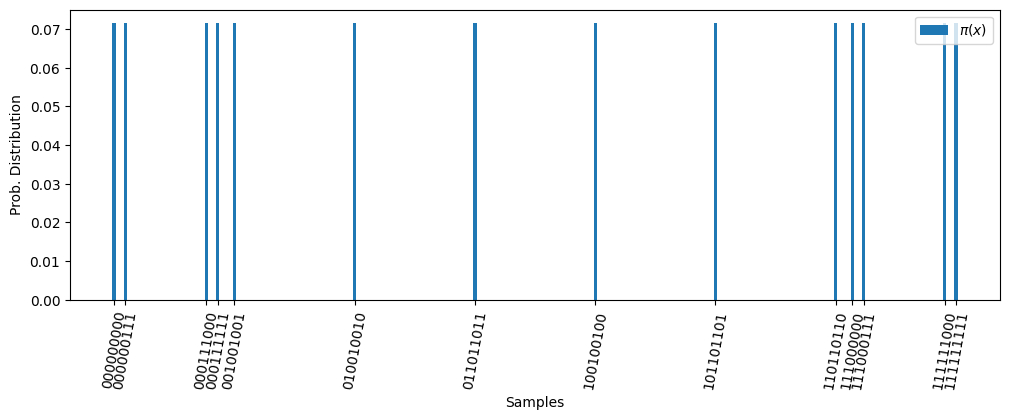

In [47]:
bitstrings = []
nums = []
for d in data:
    bitstrings += ["".join(str(int(i)) for i in d)]
    nums += [int(bitstrings[-1], 2)]
print(nums)

probs = np.zeros(2**size)
probs[nums] = 1 / len(data)

plt.figure(figsize=(12, 5))
plt.bar(np.arange(2**size), probs, width=2.0, label=r"$\pi(x)$")
plt.xticks(nums, bitstrings, rotation=80)

plt.xlabel("Samples")
plt.ylabel("Prob. Distribution")
plt.legend(loc="upper right")
plt.subplots_adjust(bottom=0.3)
plt.show()

In [48]:
np.random.seed(42)

n_qubits = size
dev = qml.device("default.qubit", wires=n_qubits)

n_layers = 6
wshape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits)
weights = np.random.random(size=wshape)

@qml.qnode(dev)
def circuit(weights):
    qml.StronglyEntanglingLayers(weights=weights, ranges=[1] * n_layers, wires=range(n_qubits))
    return qml.probs()

jit_circuit = jax.jit(circuit)

In [49]:
bandwidth = jnp.array([0.25, 0.5, 1])
space = jnp.arange(2**n_qubits)

mmd = MMD(bandwidth, space)
qcbm = QCBM(jit_circuit, mmd, probs)

opt = optax.adam(learning_rate=0.1)
opt_state = opt.init(weights)

loss_1, px = qcbm.mmd_loss(weights)  # squared MMD
loss_2 = mmd.k_expval(px, px) - 2 * mmd.k_expval(px, probs) + mmd.k_expval(probs, probs)
print(loss_1)
print(loss_2)

0.06842073068350443
0.06842073068350445


In [50]:
@jax.jit
def update_step(params, opt_state):
    (loss_val, qcbm_probs), grads = jax.value_and_grad(qcbm.mmd_loss, has_aux=True)(params)
    updates, opt_state = opt.update(grads, opt_state)
    params = optax.apply_updates(params, updates)

    log_ratio = jnp.where(qcbm.py == 0, 0, jnp.log(qcbm_probs / qcbm.py))

    kl_div = -jnp.sum(qcbm.py * log_ratio)

    return params, opt_state, loss_val, kl_div

history = []
divs = []
n_iterations = 100

for i in range(n_iterations):
    weights, opt_state, loss_val, kl_div = update_step(weights, opt_state)

    if i % 10 == 0:
        print(f"Step: {i} Loss: {loss_val:.4f} KL-div: {kl_div:.4f}")
    
    history.append(loss_val)
    divs.append(kl_div)

Step: 0 Loss: 0.0684 KL-div: 4.0735
Step: 10 Loss: 0.0439 KL-div: 1.7351
Step: 20 Loss: 0.0367 KL-div: 1.3296
Step: 30 Loss: 0.0292 KL-div: 1.0619
Step: 40 Loss: 0.0116 KL-div: 0.4977
Step: 50 Loss: 0.0039 KL-div: 0.2462
Step: 60 Loss: 0.0014 KL-div: 0.1348
Step: 70 Loss: 0.0009 KL-div: 0.1077
Step: 80 Loss: 0.0006 KL-div: 0.0852
Step: 90 Loss: 0.0004 KL-div: 0.0755


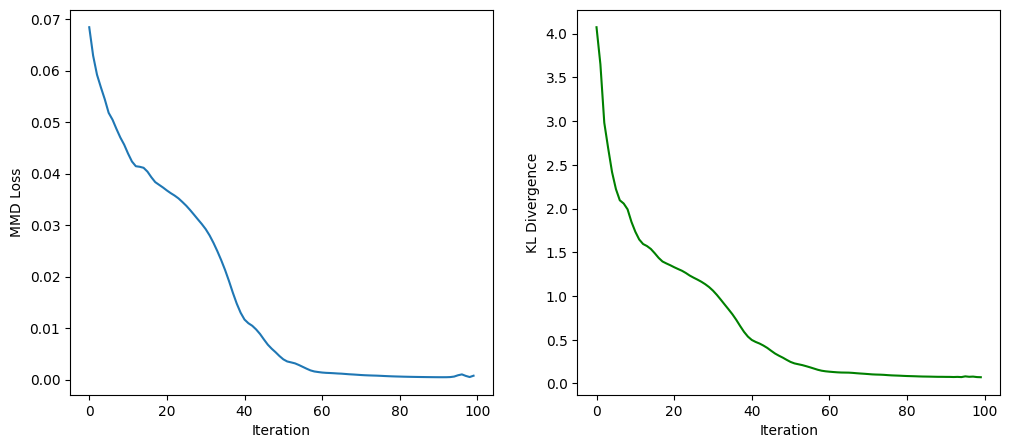

In [51]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(history)
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("MMD Loss")

ax[1].plot(divs, color="green")
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("KL Divergence")
plt.show()

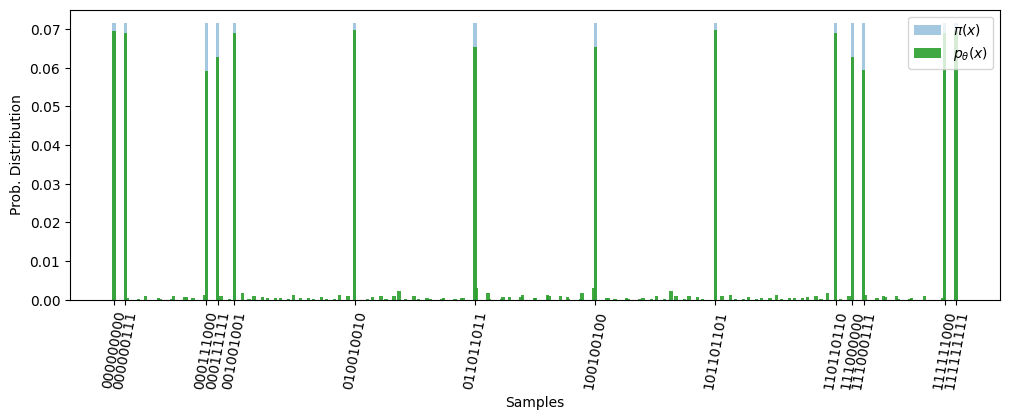

In [52]:
qcbm_probs = np.array(qcbm.circ(weights))

plt.figure(figsize=(12, 5))

plt.bar(
    np.arange(2**size),
    probs,
    width=2.0,
    label=r"$\pi(x)$",
    alpha=0.4,
    color="tab:blue",
)
plt.bar(
    np.arange(2**size),
    qcbm_probs,
    width=2.0,
    label=r"$p_\theta(x)$",
    alpha=0.9,
    color="tab:green",
)

plt.xlabel("Samples")
plt.ylabel("Prob. Distribution")

plt.xticks(nums, bitstrings, rotation=80)
plt.legend(loc="upper right")
plt.subplots_adjust(bottom=0.3)
plt.show()

In [53]:
def circuit(weights):
    qml.StronglyEntanglingLayers(weights=weights, ranges=[1] * n_layers, wires=range(n_qubits))
    return qml.sample()


for N in [2000, 20000]:
    dev = qml.device("default.qubit", wires=n_qubits)
    circ = qml.set_shots(qml.QNode(circuit, device=dev), shots = N)
    preds = circ(weights)
    mask = np.any(np.all(preds[:, None] == data, axis=2), axis=1)  # Check for row-wise equality
    chi = np.sum(mask) / N
    print(f"χ for N = {N}: {chi:.4f}")

print(f"χ for N = ∞: {np.sum(qcbm_probs[nums]):.4f}")

χ for N = 2000: 0.9280
χ for N = 20000: 0.9298
χ for N = ∞: 0.9293


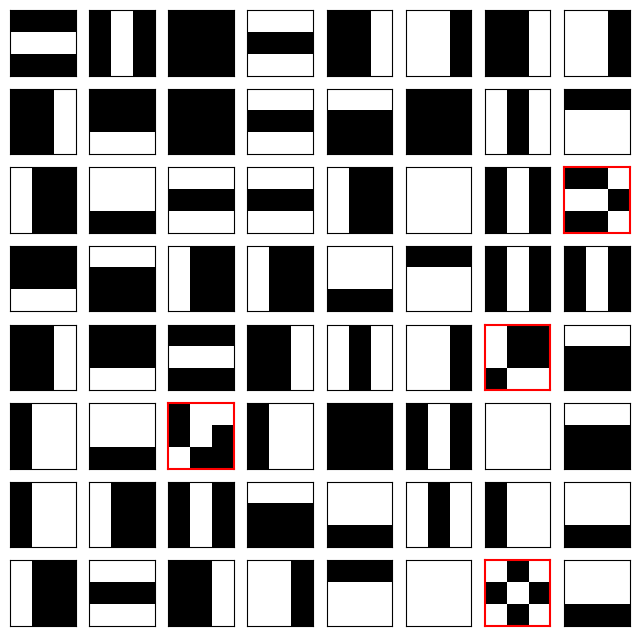

In [54]:
plt.figure(figsize=(8, 8))
j = 1
for i, m in zip(preds[:64], mask[:64]):
    ax = plt.subplot(8, 8, j)
    j += 1
    plt.imshow(np.reshape(i, (n, n)), cmap="gray", vmin=0, vmax=1)
    if ~m:
        plt.setp(ax.spines.values(), color="red", linewidth=1.5)
    plt.xticks([])
    plt.yticks([])

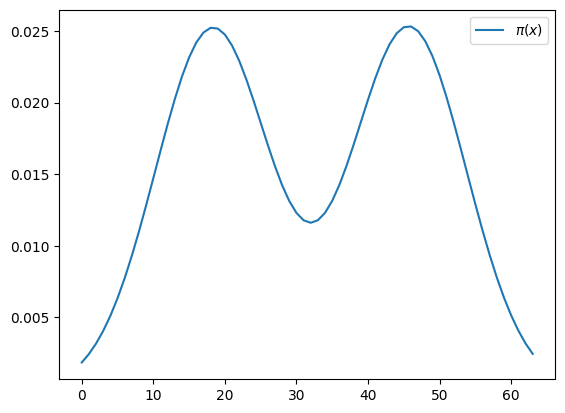

In [ ]:
#GAUSSIAN 
def mixture_gaussian_pdf(x, mus, sigmas):
    mus, sigmas = np.array(mus), np.array(sigmas)
    vars = sigmas**2
    values = [
        (1 / np.sqrt(2 * np.pi * v)) * np.exp(-((x - m) ** 2) / (2 * v)) for m, v in zip(mus, vars)
    ]
    values = np.sum([val / sum(val) for val in values], axis=0)
    return values / np.sum(values)


n_qubits = 6
x_max = 2**n_qubits
x_input = np.arange(x_max)
mus = [(2 / 7) * x_max, (5 / 7) * x_max]
sigmas = [x_max / 8] * 2
data = mixture_gaussian_pdf(x_input, mus, sigmas)

plt.plot(data, label=r"$\pi(x)$")
plt.legend()
plt.show()

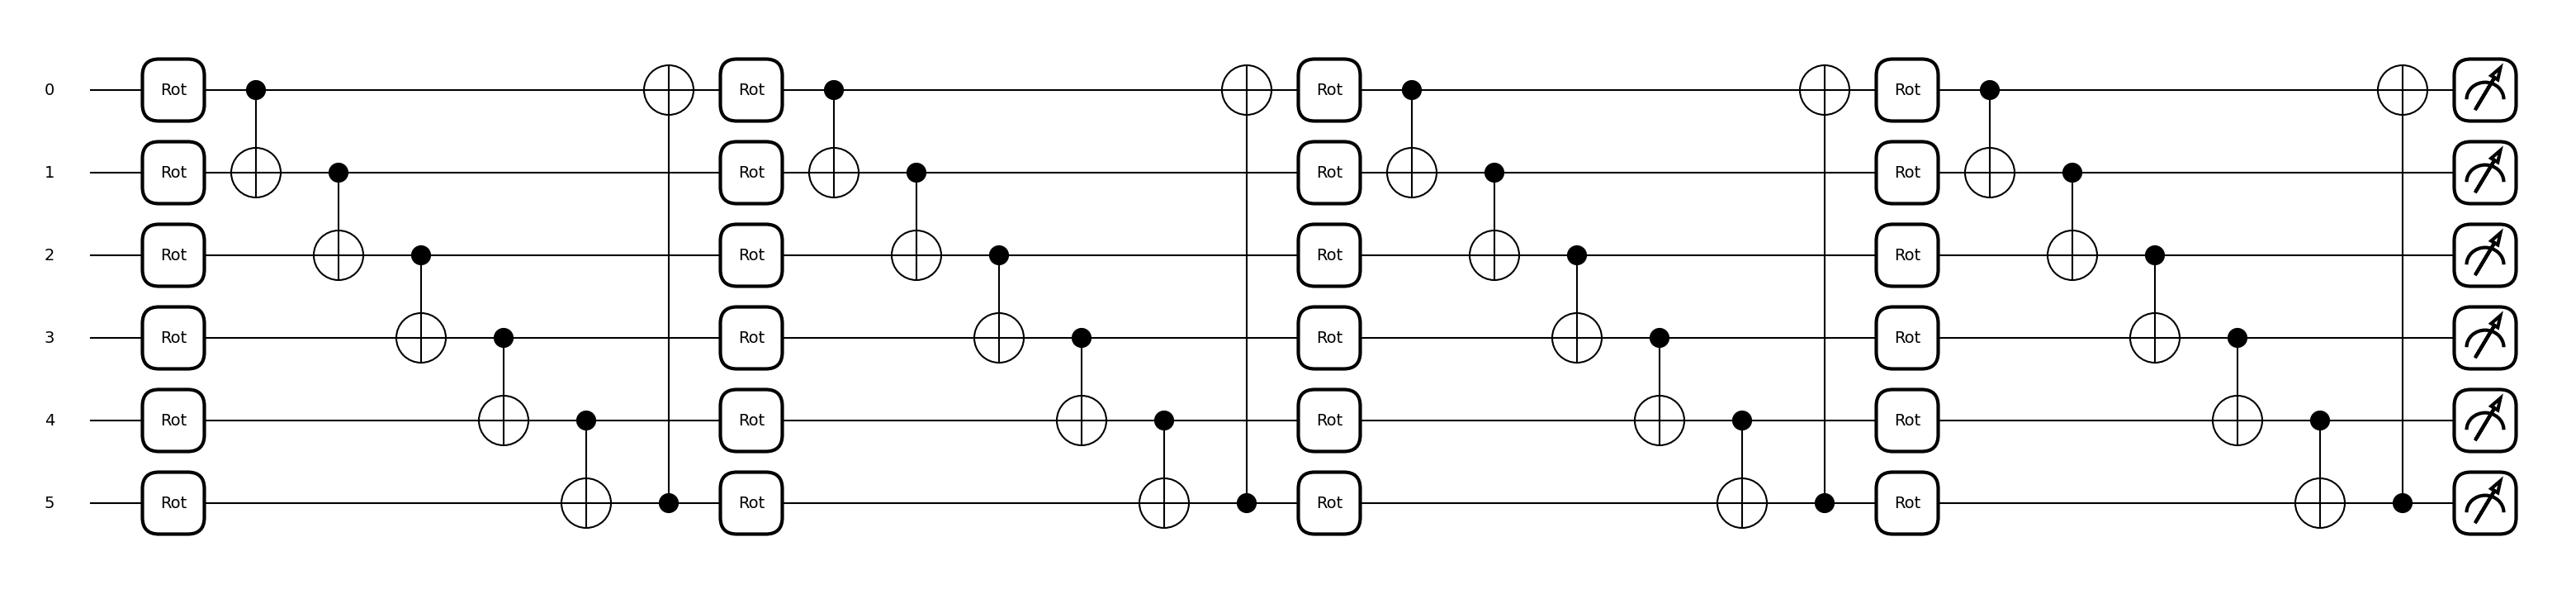

In [56]:
dev = qml.device("default.qubit", wires=n_qubits)

n_layers = 4
wshape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits)
weights = np.random.random(size=wshape)


@qml.set_shots(N)
@qml.qnode(dev)
def circuit(weights):
    qml.StronglyEntanglingLayers(
        weights=weights, ranges=[1] * n_layers, wires=range(n_qubits)
    )
    return qml.probs()


jit_circuit = jax.jit(circuit)

qml.draw_mpl(circuit, level="device")(weights)
plt.show()

In [57]:
bandwidth = jnp.array([0.25, 60])
space = jnp.arange(2**n_qubits)

mmd = MMD(bandwidth, space)
qcbm = QCBM(jit_circuit, mmd, data)

opt = optax.adam(learning_rate=0.1)
opt_state = opt.init(weights)

history = []
divs = []
n_iterations = 100

for i in range(n_iterations):
    weights, opt_state, loss_val, kl_div = update_step(weights, opt_state)

    if i % 10 == 0:
        print(f"Step: {i} Loss: {loss_val:.4f} KL-div: {kl_div:.4f}")

    history.append(loss_val)
    divs.append(kl_div)

Step: 0 Loss: 0.0264 KL-div: 0.8015
Step: 10 Loss: 0.0035 KL-div: 0.3668
Step: 20 Loss: 0.0013 KL-div: inf
Step: 30 Loss: 0.0010 KL-div: 0.0903
Step: 40 Loss: 0.0006 KL-div: 0.0871
Step: 50 Loss: 0.0005 KL-div: 0.0729
Step: 60 Loss: 0.0004 KL-div: 0.0441
Step: 70 Loss: 0.0003 KL-div: 0.0267
Step: 80 Loss: 0.0003 KL-div: 0.0282
Step: 90 Loss: 0.0002 KL-div: 0.0260


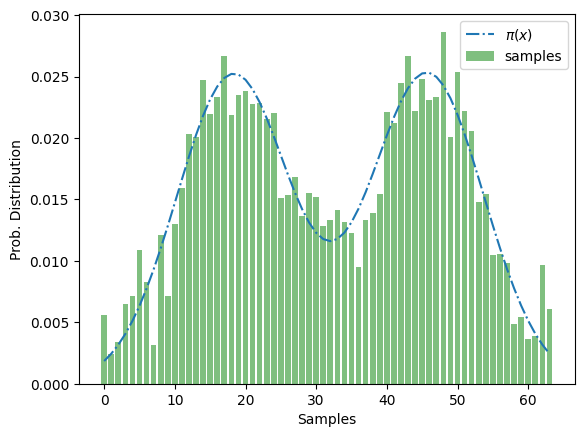

In [58]:
qcbm_probs = qcbm.circ(weights)

plt.plot(range(x_max), data, linestyle="-.", label=r"$\pi(x)$")
plt.bar(range(x_max), qcbm_probs, color="green", alpha=0.5, label="samples")

plt.xlabel("Samples")
plt.ylabel("Prob. Distribution")

plt.legend()
plt.show()